In [2]:
import seaborn as sns
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import rc
# red, blue, green, yellow, purple, orange, teal blue, pink, other color
palette=['#ff3b30', '#4cd964','#ffcc00',  '#007aff','#5856d6', '#ff9500', '#5ac8fa', '#ff2d55','#969783']
markers=['o', '^', '<', 'd', '*','2']
sns.set_style("ticks")
import matplotlib as mpl
mpl.rcParams['lines.markersize'] = 6
mpl.rcParams['lines.linewidth']=1
rc("font", **{'family':'serif','serif':['Palatino'], 'size':12})
rc('text', usetex=True)
import os

In [3]:
basepath="/home/jiangnan/PycharmProjects/scibench/plots"

In [4]:

def plot_quantile_nmse(total, name, title, metric_name, use_logy=False, show_ylabel=True, use_hatches=False):
    GP=[abs(float(line.split("\t")[0])) for line in total.split("\n")]
    CVGP=[abs(float(line.split("\t")[1])) for line in total.split("\n")]
    VPG=[abs(float(line.split("\t")[2])) for line in total.split("\n")]
    PQT=[abs(float(line.split("\t")[3])) for line in total.split("\n")]
    DSR=[abs(float(line.split("\t")[4])) for line in total.split("\n")]
    GPMELD=[abs(float(line.split("\t")[5])) for line in total.split("\n")]
    Eureqa=[abs(float(line.split("\t")[6])) for line in total.split("\n")]
    MCTS=[abs(float(line.split("\t")[7])) for line in total.split("\n")]
    CVMCTS=[abs(float(line.split("\t")[8])) for line in total.split("\n")]
    df=pd.DataFrame({
        "model": CVGP+GP+Eureqa+CVMCTS+MCTS+VPG+PQT+DSR+GPMELD,
        "type": ['VSR-GP(ours)']*10+['GP']*10+['Eureqa']*10+['VSR-MCTS(ours)']*10+['MCTS']*10+['VPG']*10+['PQT']*10+['DSR']*10+['GPMeld']*10
    })
    

    plt.figure(figsize=(3,3))
    ax=sns.boxplot(data=df, x="model", y="type", 
                   showfliers=True, 
                   width=0.5, hue='type',
                    palette=palette)
    ax.set_title(title, fontsize=16)
    ax.set(xlabel=metric_name, ylabel="")
    if use_logy==True:
        plt.xscale('log', base=10)
        
    if show_ylabel==False:
        ax.set(yticklabels=[])
    if use_hatches==True:
        hatches = ["/", "o", "*", "\\"]
        for hatch, patch in zip(hatches, ax.artists):
            patch.set_hatch(hatch)
    plt.yticks(rotation=40)    

    fname = os.path.join(basepath, name+".pdf")
    plt.savefig(fname, bbox_inches='tight', pad_inches=0)

# inv

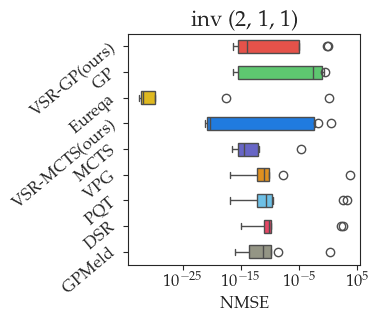

In [5]:
total="""-6.34E-16	-0.5023958169	-7.01E-11	-7.95E-11	-7.53E-12	-9.33E-17	-2.31E-33	-5.78E-15	4.13E-21
-1.56E-16	-6.86E-17	-1.70E-08	-314.0583334	-148.8699511	-1.878912601	-4.43E-33	-6.45E-13	1.52E-21
-0.174594366	-4.48E-17	-6.76E-14	-1693.544281	-303.2915793	-9.28E-12	-1.64E-32	-9.86E-13	1.48E-21
-0.004784626412	-1.43E-14	-5057.401534	-2.98E-11	-1.07E-10	-2.16E-09	-1.076357847	-6.07E-16	3.85E-21
-1.09E-16	-7.20E-16	-1.48E-17	-1.48E-17	-9.37E-16	-1.23E-11	-1.35E-32	-2.09E-16	-0.005206892508
-0.0007502427596	-9.29E-06	-2.01E-12	-9.55E-13	-8.10E-11	-6.46E-14	-1.76E-32	-7.36E-13	4.08E-21
-3.53E-17	-1.74E-16	-8.51E-16	-7.62E-16	-1.55E-10	-7.12E-16	-9.89E-33	-3.78E-16	0.01775955009
-0.003620224692	-1.002376232	-3.53E-12	-5.45E-12	-2.62E-12	-1.61E-10	-4.33E-33	-1.45E-16	1.48E-21
-0.2739448224	-6.25E-15	-5.50E-11	-2.89E-10	-3.71E-11	-5.95E-15	-2.11E-18	-2.17E-05	2.595205788
-0.1039099854	-2.82E-06	-1.23E-11	-5.40E-13	-1.22E-11	-1.05E-12	-1.80E-30	-2.65E-17	5.47E-22"""
metric_name="NMSE"
name="inv_nv2_nt11_"+metric_name
title="inv (2, 1, 1)" 
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=True)

In [6]:
total="""-6.15E-05	-0.0001470751105	-1.029302226	-1.00535428	-1.00664651	-0.36783758	-0.4628734414	-3.47E-32
-0.6224665077	-9.56E-05	-15526.72012	-0.9446089997	-3.460279398	-0.3050802364	-0.2928435565	-3.76E-32
-1.74E-16	-4.37E-08	-0.7311533622	-0.856335816	-1.004019489	-1.905563015	-0.03342303437	-2.32E-32
-0.002374797362	-0.0005407333293	-1.002877417	-1.021190151	-0.9934213752	-0.3245591531	-0.0413013162	-1.94E-32
-0.02725445725	-0.001920341018	-0.9528195742	-0.03563508133	-0.9836553981	-0.7467286677	-0.06542923283	-2.11E-32
-0.0004983656599	-0.0005455657374	-1.003968719	-1.003456089		-1.113601114	-0.05203017994	-1.93E-32
-0.05433234823	-0.000182825107	-0.899888158	-0.8920643329	-2.62074931	-104.1515412	-0.1017464859	-3.72E-13
-0.1613627198	-0.02086853276	-0.807977046	-0.8220434119	-0.9308465352	-1.01101636	-0.03020641635	-2.41E-32
-0.2139788621	-0.004557440427	-0.8843235533	-0.02169645682	-0.00777821245	-2.277979268	-0.003657731193	-1.84E-32
-3.30E-09	-0.02039203559	-1.675556656	-0.006748911256	-1.487781233	-11.38149037	-0.07491460881	-0.02718220323"""
metric_name="NMSE"
name="inv_nv3_nt22_"+metric_name
title="inv (3, 2, 2)" 
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=True)

ValueError: could not convert string to float: ''

In [ ]:
total="""-0.006914445081	-0.0003229212466	-2.595442499	-2.935496708	-1.000125655	-1.075624202	-1.003441623	-0.6191769905	-0.03335290923
-0.05530205621	-0.07741651362	-27.87129104	-0.962171648	-1.276772019	-1.109146386	-7.184151329	-0.4998898976	-0.01953987778
-0.3917759248	-0.06285200264	-1.016276163	-1.009644597	-0.8379190329	-1.578494447	-9.737934957	-0.6125833398	-0.04152753325
-0.235832488	-0.07814062043	-1.406368855	-0.9702153326	-0.8867518369	-0.9833217328	-0.8319511166	-0.322246526	-0.0003251772998
-0.05173943172	-0.04551368251	-1.007406101	-1.028874526	-1.167406832	-0.6475235167	-120.2476187	-0.4902711026	-0.009772430974
-0.01480920749	-0.003473326718	-1.034987857	-0.9990057187	-1.400079807	-1.145424506	-0.8805625575	-0.4313146821	-0.009138172894
-1.37E-05	-2.39E-05	-0.9885223766	-1121.421639	-0.9315904392	-1.012251753	-1.378763634	-0.3288993106	-7.83E-05
-0.003332676537	-0.005680629326	-1.502336468	-0.8817521535	-1.012329105	-2.521244808	-2.449366653	-0.5864014373	-0.1192269936
-0.008663030214	-0.001964239112	-200.0687876	-2648.254885	-144.6839238	-47.27860264	-0.4557840157	-0.556073817	-0.121376045
-0.009524937612	-0.0105291884	-1.008174897	-1.002995514	-1.000647868	-11.47274996	-0.6453185538	-0.4362240519	-0.01440130069"""
metric_name="NMSE"
name="inv_nv4_nt46_"+metric_name
title="inv (4, 4, 6)" 
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=True)

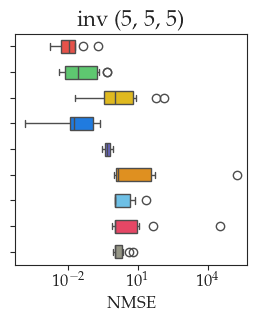

In [7]:
total="""-0.008000770224	-0.003684561356	-1.473119071	-1.048935301	-1.008947831	-1.014722117	-0.9964901389	-0.8510794088	-0.01190596253
-0.2111516417	-0.04362472286	-49.92201556	-5.407006887	-46.16258094	-0.8092755223	-1.161165603	-0.3927473105	-0.0001417983349
-0.02657944965	-0.008854562064	-1.329265038	-1.012027156	-1.016370923	-3.998141133	-133.867712	-0.645604709	-0.2349802083
-0.003878338569	-0.01042018968	-3.287986184	-1.008046881	-0.9984072499	-1.00056465	-60.8013219	-0.5140332217	-0.2295648935
-0.4732543611	-0.1883507981	-0.9757530679	-21.24279999	-10.83369293	-0.9391020365	-0.07111232162	-0.272600382	-0.01288708333
-0.006488188129	-0.001632370329	-1.082431366	-1.024139371	-0.7874298236	-1.008837954	-0.1649647628	-0.3247006413	-0.01732719528
-0.005288096504	-0.00174539829	-182910.9524	-2.721678408	-1.060504455	-2.286429081	-8.066164272	-0.5054197093	-0.009450562969
-0.488241117	-0.01129763364	-54.52545632	-7.679155739	-36000.83306	-6.28153215	-0.01860477639	-0.4257852386	-0.01704113629
-0.07388120174	-0.01817349584	-1.002271881	-1.023422988	-1.011930831	-1.00713374	-0.952938683	-0.3899805708	-0.1125705155
-0.02404659297	-0.01917287392	-1.20104114	-1.047736305	-2.717392239	-1.004833669	-0.9947576896	-0.8495296078	-0.1058478116"""
metric_name="NMSE"
name="inv_nv5_nt55_"+metric_name
title="inv (5, 5, 5)" 
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=False)

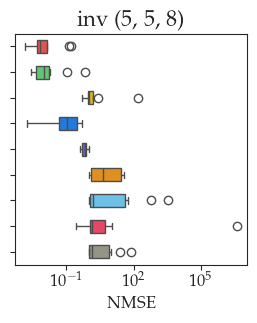

In [8]:
total="""-0.1075903232	-0.1529989472	-31.25430576	-3.377255867	-1.347076542	-1.016864334	-2.4755483	-0.4267895364	-0.001777465296
-0.004225765473	-0.007656379334	-6.5860101	-3518.706886	-4139144.479	-77.72732696	-0.9862846621	-0.3985156377	-0.2497220944
-0.002657787572	-0.003121036133	-32.27852153	-53.90534444	-4.480019855	-10.03649198	-0.8862319081	-0.9830776298	-0.3133620367
-0.01754918503	-0.006042118162	-36.53800111	-582.0606122	-0.2687051325	-24.68258643	-1.002676012	-0.7317842694	-0.05176676423
-0.0048347351	-0.1237862683	-1.001969626	-1.031512776	-1.022385938	-1.010986777	-1.540504148	-0.9591253104	-0.4107037048
-0.6973264353	-0.01244632316	-1.263217023	-1.45738411	-1.45868073	-1.643435977	-1.360037783	-0.6009377729	-0.1082974242
-0.009760111211	-0.01382396283	-1.679468887	-1.553496974	-5.387960158	-1.12844679	-0.4954894948	-0.7859596265	-0.4997086046
-0.009418754763	-0.004328835007	-15.90740585	-1.04395837	-1.314576292	-1.074063437	-153.918496	-0.6019681886	-0.002555106584
-0.002528624547	-0.001468401802	-1.457237615	-1.506737805	-10.98774002	-2.257037782	-1.001018545	-0.4467641936	-0.09595341595
-0.01591179961	-0.006029463559	-1.001976092	-1.002999788	-1.016592457	-0.998179854	-0.8430071605	-0.7554216474	-0.04487066693"""
metric_name="NMSE"
name="inv_nv5_nt58_"+metric_name
title="inv (5, 5, 8)" 
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=False)

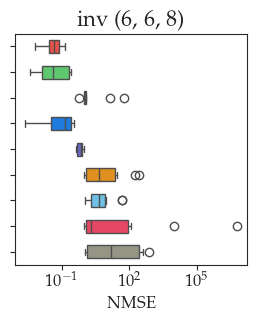

In [9]:
total="""-0.0117536851	-0.01468288374	-1.724002726	-1.802038957	-113.954191	-1.482369136	-1.005326531	-0.4267895364	-0.03333733264
-0.04468178696	-0.03881604688	-1.087834894	-48.23357149	-6033774.929	-1.253325519	-0.9627972027	-0.3985156377	-0.3534354021
-0.03182456422	-0.04746429375	-257.0223601	-46.05036872	-2.20562355	-1.189987254	-56.50573858	-0.9830776298	-0.1945656993
-0.1234422447	-0.06704433634	-11.14554435	-1.019049399	-9405.046128	-336.8180349	-0.9992414071	-0.7317842694	-0.002338649142
-0.2256165169	-0.09339681138	-176.5138148	-9.087438402	-1.053575071	-1.292322546	-1.008744469	-0.9591253104	-0.1925828195
-0.2460982542	-0.07665185952	-1.130597653	-2.203899615	-1.567933036	-29.67740509	-0.5698100508	-0.6009377729	-0.2577778011
-0.005486793723	-0.04039016782	-7.125429839	-1.244449868	-1.721278379	-406.1447006	-1.00541672	-0.7859596265	-0.01382464051
-0.01779787252	-0.0217491015	-1.316749547	-3.33201717	-0.9972815283	-1.013605158	-0.9967118881	-0.6019681886	-0.334727553
-0.003612852018	-0.006522373537	-0.9954888015	-5.09290279	-1.023456374	-67.93006808	-13.03277655	-0.4467641936	-0.07069812712
-0.23103834	-0.129800763	-26.83148027	-5.513348874	-20.25153929	-711.4154579	-1.196615116	-0.7554216474	-0.0310282791"""
metric_name="NMSE"
name="inv_nv6_nt68_"+metric_name
title="inv (6, 6, 8)"
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=False)

# sin cos

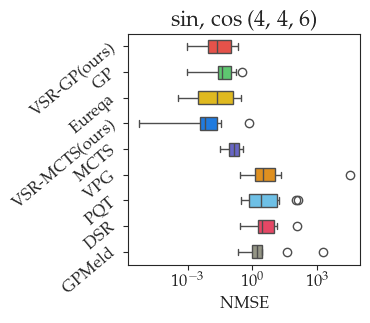

In [10]:
total="""-0.02279089019	-0.01720397622	-1.928834945	-1.973065132	-1.807313086	-2.344868266	-0.109563115	-0.04429012341	-0.03647221263
-0.07579673929	-0.0009105627062	-33571.8839	-110.3384671	-11.67789932	-1864.142841	-0.0003389016116	-0.1701373077	-0.02529951857
-0.1663137703	-0.131794477	-2.811462568	-2.789374538	-2.657500015	-2.529248212	-0.1326339923	-0.1034560373	-0.003702869478
-0.04366428173	-0.01750627082	-1.010211591	-1.137828398	-0.9773504079	-0.9952799437	-0.001774210648	-0.33545558	-5.22E-06
-0.3416898582	-0.2199451963	-3.194291471	-2.886154422	-2.973103344	-2.753002357	-0.001111196934	-0.2374734444	-0.01084121892
-0.001342166648	-0.001342166648	-0.2658650581	-0.2839344921	-0.2722951447	-0.2201402031	-0.006915832854	-0.08097769056	-0.006196774656
-0.02800431197	-0.02800431197	-22.11554265	-135.9363262	-1.96712722	-0.9226298429	-0.1257112507	-0.3672323787	-0.006634767589
-0.0008985419461	-0.005354488181	-3.167650788	-0.3639842544	-113.4883446	-0.7576647115	-0.02878101479	-0.212539058	-0.003886542983
-0.03588675532	-0.0309483116	-1.139015806	-0.5758759331	-4.797776171	-0.9485044945	-0.01923825875	-0.03156100581	-0.002954038908
-0.1061348516	-0.1979560891	-14.02267298	-17.49595912	-13.9881551	-40.02616197	-0.29065399	-0.1176917492	-0.7327106375"""
metric_name="NMSE"
name="sincos_nv4_nt46_"+metric_name
title="sin, cos (4, 4, 6)"
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=True)


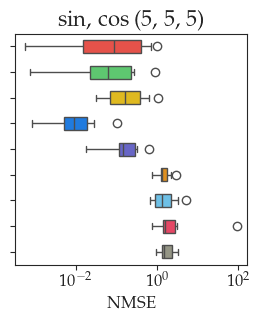

In [11]:
total="""-0.2763223875	-0.1392030414	-2.869942759	-2.430842689	-1.763310293	-2.767693569	-0.185791877	-0.2871561781	-0.004585544599
-0.01497302403	-0.01075301785	-1.876463097	-1.498537514	-3.091040551	-1.162862343	-0.1298179983	-0.08308503746	-0.0008453332233
-0.1287550014	-0.1214458873	-2.173634594	-3.225709767	-0.7583644235	-2.295888596	-0.09388815122	-0.3276837455	-0.01588480758
-0.005444479887	-0.0005686049854	-1.208865406	-0.6729495629	-1.484360581	-3.274598	-0.04896681925	-0.01807244637	-0.1003354663
-0.891744316	-0.6864236881	-1.337811005	-1.271491891	-1.461739172	-1.474228455	-0.6203487184	-0.6433437629	-0.005999437041
-0.07406748266	-0.01231006794	-1.275614684	-0.7874055482	-91.54055676	-0.9545260351	-0.03199263909	-0.2602441296	-0.004923885659
-0.04509417768	-0.05016402953	-0.7351629008	-0.730313939	-1.108979024	-1.277514706	-1.078163312	-0.1541737731	-0.02017685339
-0.0007560725642	-0.02320406824	-1.499418763	-5.135332837	-3.16781443	-2.29263307	-0.298325541	-0.1146991715	-0.00500614278
-0.05141829785	-1.003993707	-1.305800764	-1.415305274	-1.701676465	-1.527237966	-0.4031756773	-0.1400943035	-0.02781036703
-0.2663470803	-0.4892650733	-0.8506269865	-1.094368236	-1.387925503	-1.340359072	-0.06039698663	-0.1126471068	-0.01184919932"""
metric_name="NMSE"
name="sincos_nv5_nt55_"+metric_name
title="sin, cos (5, 5, 5)"
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=False)


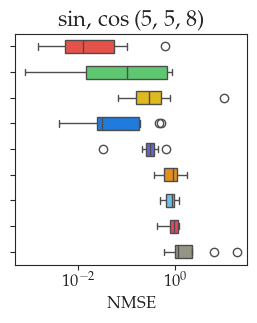

In [12]:
total="""-0.02424457697	-0.0114873252	-0.9043881979	-0.8720357627	-1.160042091	-2.245443999	-0.7636005885	-0.2751598897	-0.02638486694
-0.1306994031	-0.002616774497	-0.5625655424	-0.4847951406	-0.5198150985	-0.7021756539	-0.2490839071	-0.3139199374	-0.1913428807
-0.0008210799363	-0.001482637269	-1.039344266	-0.9683662562	-0.9901376775	-0.9946609157	-0.1494344663	-0.03294848876	-0.003941995922
-0.01101247514	-0.02243749151	-1.750376422	-1.010073718	-0.8997949056	-1.253620433	-0.3195606346	-0.3475203971	-0.1454833853
-0.3421258511	-0.1021754133	-1.119190769	-1.170317376	-1.172823991	-6.215169908	-0.1393161841	-0.2993592377	-0.02933186435
-0.002204343045	-0.003725206325	-0.6878131968	-0.6831733699	-1.161085033	-0.9644313637	-0.5329667991	-0.2111291129	-0.0097415689
-0.7968367042	0.01	-1.098811635	-0.9258467887	-1.044022809	-0.9666826809	-0.4553267188	-0.3726637827	-0.03365529624
-0.8510269683	-0.06638316762	-0.3589836076	-0.5590410598	-0.412343172	-18.49722613	-0.06670663369	-0.6535421714	-0.4974247843
-0.8516390249	-0.6091739698	-0.8667444598	-0.8386087797	-0.7814447078	-2.173367946	-0.175485841	-0.443214565	-0.02320521642
-0.07429692221	-0.01397144891	-0.5567190486	-0.6458600183	-0.7993332789	-0.5955913622	-9.940828108	-0.242736211	-0.4665994078"""
metric_name="NMSE"
name="sincos_nv5_nt58_"+metric_name
title="sin, cos (5, 5, 8)"
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=False)



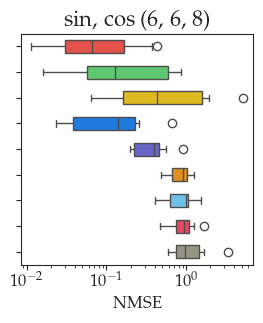

In [13]:
total="""-0.07776692385	-0.03163293647	-0.4993945359	-1.531906634	-1.676576011	-1.421789695	-1.908071855	-0.4629972467	-0.09232262775
-0.1125013521	-0.01147311954	-1.002828423	-0.7098874695	-0.8937912844	-0.5943334608	-0.3724374409	-0.1975220192	-0.06035370333
-0.1414031735	-0.02961028014	-0.7403071793	-0.5564070302	-0.7165705547	-0.7257135433	-0.3249701553	-0.3443996177	-0.2193023046
-0.338816671	-0.3684869855	-0.4835250693	-0.4099676538	-0.4632643041	-1.673776426	-0.4932620306	-0.1960961194	-0.02415420041
-0.04926049332	-0.04961551231	-1.250696655	-0.9747763724	-1.235430494	-1.122489791	-1.720288665	-0.24195135	-0.02340382609
-0.01611595421	-0.02767246338	-1.153595875	-1.01801548	-1.109311704	-3.332629481	-0.08648862487	-0.5582230159	-0.03077682738
-0.02624827142	-0.08324956805	-0.859064244	-1.064095497	-0.9779241392	-0.7848666421	-5.083491811	-0.2100775251	-0.2342026854
-0.6748852581	-0.1813620913	-1.022614164	-0.9910214754	-0.9887153535	-1.429625797	-1.095419233	-0.4443109485	-0.1861338792
-0.8662736482	-0.4265198637	-0.9410313521	-1.126492543	-0.8414160129	-0.7290656429	-0.10507637	-0.4377970906	-0.6699727386
-0.7021880692	-0.1209608798	-0.6262835324	-0.6031580321	-0.6072940972	-0.8057822189	-0.06404652003	-0.9057814438	-0.254985959"""
metric_name="NMSE"
name="sincos_nv6_nt68_"+metric_name
title="sin, cos (6, 6, 8)"
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=False)

# sin cos inv

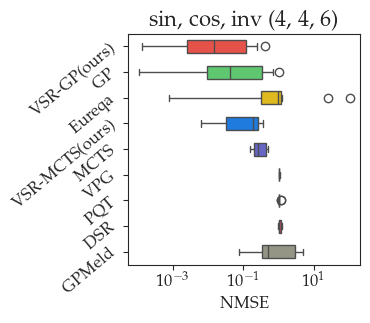

In [14]:
total="""-1.055575878	-0.08786625301	-1.024268231	-1.045604707	-1.165065646	-0.3293195432	-0.7491277241	-0.1937789498	-0.0512340348
-0.0147585338	-0.001362967903	-1.048259987	-1.011136173	-1.293372646	-0.3565873727	-0.9722201708	-0.509300218	-0.222466967
-0.06781130293	-0.01441582324	-1.107538062	-1.202011982	-1.180172766	-0.3609630159	-0.9951184844	-0.1937789498	-0.0274693202
-0.4250380122	-0.2488117579	-1.086569356	-1.004117191	-1.049925338	-2.623474279	-106.4438006	-0.2606037365	-0.2569644388
-0.0001088010805	-0.0006773911883	-1.026537054	-1.032354496	-1.030324506	-0.2280651171	-0.0007723321503	-0.1540237864	-0.006557367004
-0.7260992247	-0.4061375152	-1.008858675	-1.008246509	-1.004657065	-5.013733977	-1.000025709	-0.4776766474	-0.2772855161
-0.114627694	-0.1325737935	-1.049929788	-1.149594997	-1.124901367	-0.6297670883	-1.261432021	-0.2414236688	-0.1635677227
-0.00800543633	-0.006029623602	-1.02391109	-1.057668699	-0.997782996	-3.175947158	-0.1656631641	-0.3010936105	-0.3019781743
-0.001400292634	-0.0001406831925	-1.05627865	-1.001911528	-1.021012287	-3.622080508	-25.59355268	-0.2565175187	-0.01202875894
-0.01599220037	-0.01580478159	-1.071536071	-1.048677872	-1.026352251	-0.0763665659	-0.02828311304	-0.4917732489	-0.3671455118"""
metric_name="NMSE"
name="sincosinv_nv4_nt46_"+metric_name
title="sin, cos, inv (4, 4, 6)"
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=True)

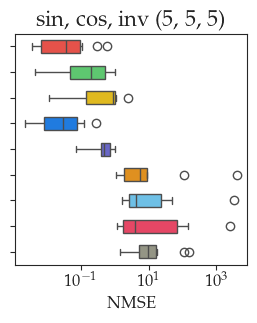

In [15]:
total="""-0.4504560722	-0.07067758923	-1.125831564	-2.528583842	-5.327766572	-1.402046824	-0.1621606959	-0.4573037168	-0.03649377362
-0.1479058146	-0.004293009658	-1.242810366	-4.390516512	-1.165278627	-2.106075385	-0.01132739281	0.5	-0.008313135969
-0.004322532813	-0.004322532813	-4000.18957	-26.6605118	-141.4917637	-155.9896849	-0.9998071541	-0.3559228069	-0.128078915
-0.245637141	-0.1060187969	-3.592644935	-49.95248224	-1.170434637	-5.242989555	-1.0079799	-1.008442674	-0.2884449925
-0.1302257597	-0.0603552076	-8.418306946	-3265.617434	-89.65012864	-13.49978993	-0.1411660826	-0.4824560699	-0.08322555008
-0.5345950107	-0.6114990748	-107.2316443	-14.64243752	-2599.53198	-109.0269791	-1.003690085	-0.9119949542	-0.002323763738
-1.00085528	-0.3016476104	-1.687300488	-1.777306526	-2.455792202	-7.968453567	-0.8014608235	-0.8115019461	-0.008290107853
-0.588993293	-0.01329994145	-8.979101488	-4.231753523	-1.775466592	-18.05804218	-2.535879027	-0.5616033891	-0.05531137541
-0.01443249787	-0.01526697801	-2.677940436	-1.680051154	-10.95082753	-5.320561081	-1.058985081	-0.07430260379	-0.02286775777
-0.01954233426	-0.003642812788	-7.491421534	-2.661844714	-1.746177585	-11.13843822	-0.02060780995	-0.3436836962	-0.007097704511"""
metric_name="NMSE"
name="sincosinv_nv5_nt55_"+metric_name
title="sin, cos, inv (5, 5, 5)"
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=False)

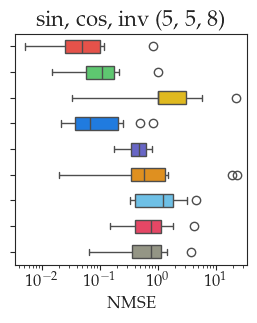

In [16]:
total="""-0.01481053405	-0.006973262935	-0.3161777256	-0.3833702712	-0.6597413836	-0.5781867344	-0.7787860808	-0.7099957081	-0.08809870666
-0.09628957829	-0.005258117127	-0.5714476498	-1.867915688	-4.182573588	-0.3544993342	-1.005639302	-0.4532229202	-0.06634990299
-0.04223113935	-0.06656592554	-1.498455923	-1.623175137	-1.047280457	-3.835531456	-1.007268315	-0.4961313793	-0.2529092003
-0.1571275086	-0.08212699001	-0.4446256894	-0.3285499585	-0.3532063662	-0.3950526569	-3.83783007	-0.4940428146	-0.03837560943
-0.113759844	-0.1212791843	-0.1441079431	-1.638811962	-0.558161923	-1.151585236	-1.003088809	-0.3161642657	-0.03709839054
-1.000000036	-0.8274184718	-19.40615622	-4.630660136	-1.148720995	-1.479001536	-5.725608891	-0.1742753006	-0.07084299738
-0.1837313114	-0.0289268177	-0.5721236879	-0.4794667233	-1.835437467	-0.9786820444	-1.051669487	0.8	-0.827263056
-0.04576477348	-0.03304141651	-0.8325432101	-0.8110556002	-0.1616257846	-0.1885845103	-1.000809731	-0.4268347374	-0.4973211475
-0.2149880937	-0.02455581375	-0.01965243623	-0.3563077229	-0.9049474783	-1.167717427	-22.62981961	-0.3175219982	-0.02184124966
-0.1084703389	-0.1084703389	-23.21994771	-3.229981884	-0.1488483777	-0.06527839806	-0.03340966434	-0.664327528	-0.02395531763"""
metric_name="NMSE"
name="sincosinv_nv5_nt58_"+metric_name
title="sin, cos, inv (5, 5, 8)"
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=False)

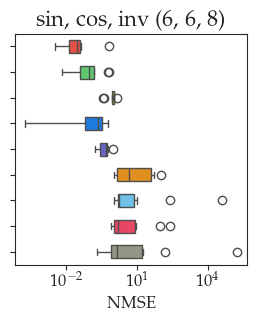

In [17]:
total="""-0.604696462	-0.6207458275	-6.012211393	-1.589120858	-0.7808279045	-11.2116077	-1.001847403	-0.510118626	-0.3894897886
-0.1439916897	-0.03036992761	-2.024008716	-2.512474199	-5.275623346	-0.2058170248	-1.001619533	-0.2603940484	-0.0001793629158
-0.6224803641	-0.03903417191	-50.03011198	-9.539427431	-8.915244782	-0.3909171759	-0.9827955023	-0.54969816	-0.2193023046
-0.1531189798	-0.03489039673	-1.032799528	-1.315462044	-1.918023947	-18.39960868	-1.399494489	-0.9954680146	-0.3607541848
-0.10731332	-0.0117784977	-4.536124627	-1.069455176	-1.290977558	-0.7613438805	-1.027891474	-0.1682051995	-0.6015057128
-0.0345587997	-0.02835865683	-1.171930378	-1.761765073	-0.994651044	-1.806962326	-0.8421451766	-0.5551386758	-0.2334717156
-0.05350398943	-0.04005300688	-4.846104682	-1.510817448	-1.226882436	-0.9783965979	-1.084917354	-0.5649220392	-0.2342026854
-0.008492745194	-0.003330293888	-52.83173678	-42905.21851	-247.0122036	-156.6625064	-0.3816218416	-0.1682178153	-0.05355274012
-0.006736857086	-0.004811106972	-1.05519113	-1.674669412	-1.005693794	-174494.8792	-1.05234285	-0.3355282511	-0.008038051677
-0.07480275937	-0.01788945998	-108.8345576	-258.6196898	-94.39130508	-0.9893044889	-0.3564198428	-0.4409398661	-0.07795290014"""
metric_name="NMSE"
name="sincosinv_nv6_nt68_"+metric_name
title="sin, cos, inv (6, 6, 8)"
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=False)

In [18]:
total="""-0.05476207842	-0.00488706224	-1.744268289	-1.228596501	-1.566316642	-3.332205656	-1.000121169
-0.08299596624	-0.01739186896	-1.13461044	-2.069440462	-1.348271787	-5.028977764	-15526.98444
-0.2212239784	-0.01349735229	-79.76324985	-1.164431522	-15.27326293	-1.609243064	-0.9909133427
-0.1130336903	-0.1440854724	-2.031718952	-1.712261912	-2.068660901	-1.109934131	-0.5177834294
-0.9777204867	-0.3032524162	-1.602303626	-1.882544262	-1.089362341	-17.32438281	-1.010029671
-0.09016479459	-0.003278094884	-1.206917787	-1.022501415	-2.09804129	-1.035599829	-1.000922931
-0.2885578656	-0.739483033	-2.177372221	-5.338039399	-1.481606514	-1.427454091	-1.003098391
-0.005627136564	-0.02048014252	-97.13470863	-355.7959504	-55.37909043	-10.03543024	-1.009270146
-0.02500265803	-0.0009982816252	-0.9879885076	-1.162894463	-26.32831498	-249.4820943	-0.9468196219
-0.02395190961	-0.01945975003	-46.54209942	-60.72706735	-994.962085	-1.847121668	-0.9700736366"""
metric_name="NMSE"
name="sincosinv_nv6_nt610_"+metric_name
title="sin, cos, inv (6, 6, 10)"
plot_quantile_nmse(total, name, title,metric_name=metric_name, use_logy=True, show_ylabel=True)

IndexError: list index out of range